# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction 

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [4]:
# Step 1: Importing libraries
# I am importing pandas for data manipulation and analysis, numpy for numerical operations, and matplotlib/seaborn for visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Step 2: Loading my dataset 
df = pd.read_csv("medical_insurance.csv")

> I want to determine whether lifestyle and health factors have an impact on medical costs. By analyzing these variables and their relationship to insurance charges, we can assess whether they provide enough signal to classify someone as a high‑cost patient. 
> Business question: Can we predict high medical costs based on lifestyle and health factors?

## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [7]:
# Step 1: Inspecting the basic structure of the dataframe
print("Dataset shape:", df.shape)

Dataset shape: (100000, 54)


> The dataset contains 100,000 records (rows) and 54 features (columns).
> The wide feature set includes demographic, medical, and insurance-related variables.

In [9]:
# Step 2: Previewing the first few rows
# This helps me understand what the data looks like and confirm it loaded correctly.
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [10]:
# Step 3: Checking column names and data types
# This tells me what kind of data each column holds (numeric, categorical, etc.).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

> Data types overview:
> - 31 integer columns: represent counts, IDs, or categorical encodings (e.g., age, 
> claims_count, household_size).
> - 13 float columns: continuous numeric measures such as income, bmi, systolic_bp, 
> annual_medical_cost.
> - 10 object columns: categorical/text features like sex, region, plan_type.
>
> Missing values:
> - Only 'alcohol_freq' has missing data (69,917 non-null out of 100,000).


In [11]:
# Step 4: Checking the 'alcohol_freq' column before making any replacements or cleaning decisions

df["alcohol_freq"]

0               NaN
1            Weekly
2               NaN
3               NaN
4             Daily
            ...    
99995    Occasional
99996    Occasional
99997        Weekly
99998    Occasional
99999           NaN
Name: alcohol_freq, Length: 100000, dtype: object

In [12]:
# Step 5: Replacing the NaN values with "No frequency"

df["alcohol_freq"] = df["alcohol_freq"].fillna(value='No Frequency')

In [13]:
# Step 6: Checking to make sure I replaced the missing values in alchohol freq
df.isnull().sum()  

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

In [14]:
# Step 7: Looking at summary statistics for numeric columns 
# This gives me a quick overview of distributions (mean, min, max, quartiles). 
 
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [15]:
# Step 8: Check for missing values 
# Important to know if I need to clean or impute data later
df.isnull().sum()  

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

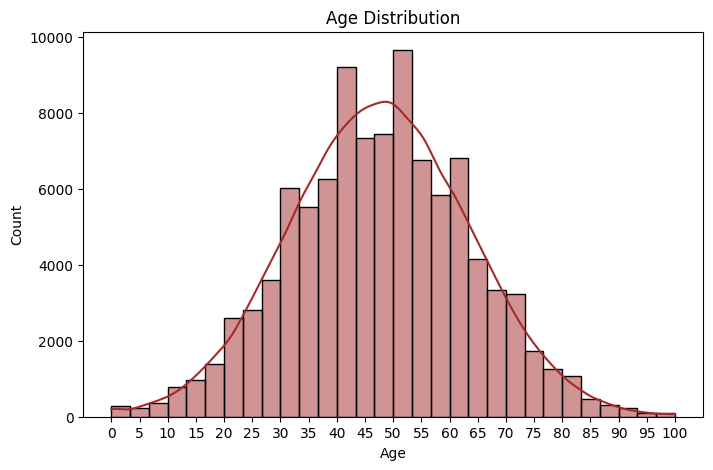

In [36]:
# Step 1: Distribution of age
# I want to see the age distribution to understand the population spread.

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='brown')
plt.xticks(ticks=range(0, 105, 5)) # Show ticks from 0 to 100 in steps of 5
plt.title("Age Distribution")
plt.xlabel("Age") 
plt.ylabel("Count")
plt.show()

> The age distribution appears roughly normal, with most individuals between 45 and 55 years old.
> This suggests the dataset is centered around middle-aged adults, which may influence medical cost trends.


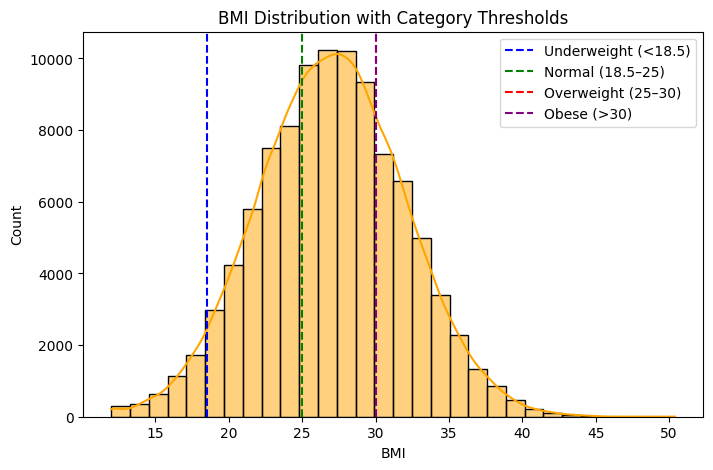

In [ ]:
# Step 2: BMI distribution with category lines
# I created BMI categories: Underweight <18.5, Normal (18.5-25), Overweight (25–30), Obese (>30) based on NIH guidelines.

plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=30, kde=True, color='orange')

plt.axvline(x=18.5, color='blue', linestyle='--', label='Underweight (<18.5)')
plt.axvline(x=25, color='green', linestyle='--', label='Normal (18.5–25)')
plt.axvline(x=30, color='red', linestyle='--', label='Overweight (25–30)')
plt.axvline(x=30, color='purple', linestyle='--', label='Obese (>30)')

plt.title("BMI Distribution with Category Thresholds")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.legend()
plt.show()


This chart shows how people’s BMI is spread out, and the lines mark where each BMI category begins. It helps to quickly see which BMI ranges most people fall into. Most individuals fall in the 25–30 range, indicating overweight.

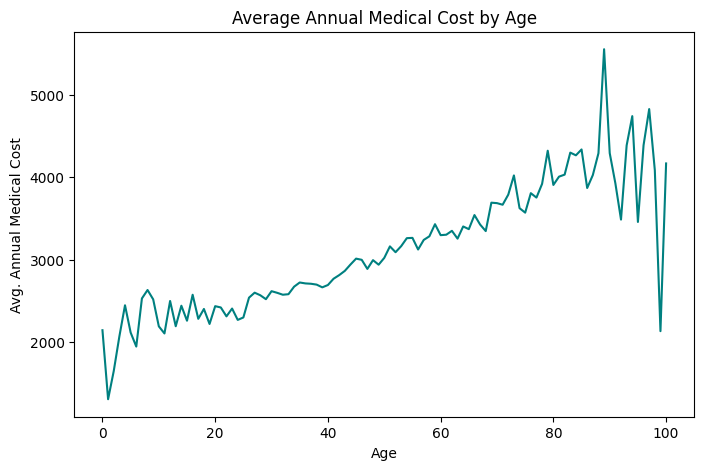

In [ ]:
# Step 3: Age vs Average Annual Medical Cost
# I want to see if costs increases or decreases with age.

avg_cost_by_age = df.groupby('age')['annual_medical_cost'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='age', y='annual_medical_cost', data=avg_cost_by_age, color='teal')
plt.title("Average Annual Medical Cost by Age")
plt.xlabel("Age")
plt.ylabel("Avg. Annual Medical Cost")
plt.show()

> Average medical costs rise steadily with age, especially after 40. This trend supports the idea that age is a strong driver of the annual medical cost. 

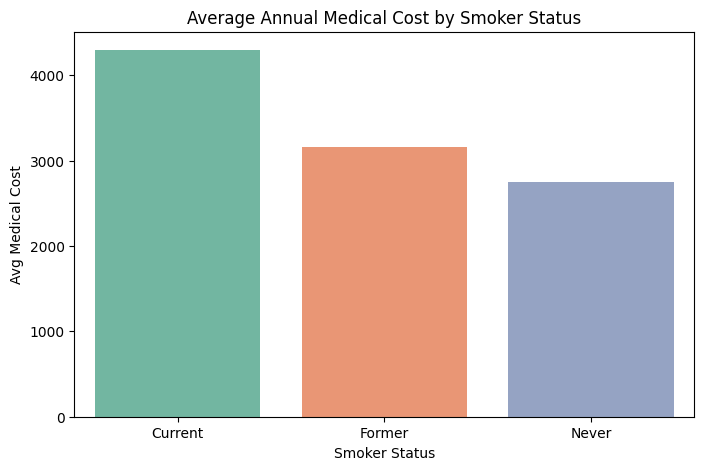

In [ ]:
# Step 4: Average Annual Medical Cost by Smoker Status
# I want to compare costs between smokers and non-smokers.

# Grouping by smoker status to calculate average medical cost
avg_cost_by_smoker = df.groupby('smoker')['annual_medical_cost'].mean().reset_index()

# Building the bar plot 
plt.figure(figsize=(8,5))
sns.barplot(x='smoker', y='annual_medical_cost', hue='smoker', data=avg_cost_by_smoker, palette='Set2', legend=False)
plt.title("Average Annual Medical Cost by Smoker Status")
plt.xlabel("Smoker Status")
plt.ylabel("Avg Medical Cost")
plt.show()

This pattern shows that people who smoke tend to have much higher medical costs than those who don’t.

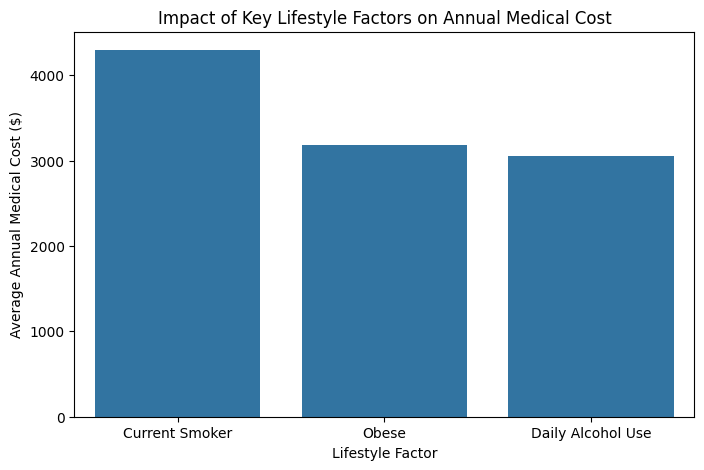

In [ ]:
# Step 5: Which lifestyle factor has the highest impact on annual medical cost?

# I am creating BMI categories so we can identify who is obese. 
# Underweight <18.5, Normal (18.5-25), Overweight (25–30), Obese (>30) based on NIH guidelines.

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# I calculate average cost for the three high‑impact categories
obese_cost = df[df['bmi_category'] == 'Obese']['annual_medical_cost'].mean()
smoker_cost = df[df['smoker'] == 'Current']['annual_medical_cost'].mean()
daily_alcohol_cost = df[df['alcohol_freq'] == 'Daily']['annual_medical_cost'].mean()

# Create a simple comparison DataFrame
comparison = pd.DataFrame({
    'Lifestyle Factor': ['Obese', 'Current Smoker', 'Daily Alcohol Use'],
    'Average Annual Cost': [obese_cost, smoker_cost, daily_alcohol_cost]})

# Sort from the highest to the lowest
comparison = comparison.sort_values('Average Annual Cost', ascending=False)

# Building the Plot
plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x='Lifestyle Factor', y='Average Annual Cost')
plt.title("Impact of Key Lifestyle Factors on Annual Medical Cost")
plt.ylabel("Average Annual Medical Cost ($)")
plt.show()


In this chart I compared three lifestyle factors — being obese, being a current smoker, and drinking alcohol daily — to see which group has the highest average annual medical cost. It helps reveal which behavior — obesity, smoking, or daily alcohol use — is associated with the highest healthcare spending. This made the insight much clearer — current smokers had the highest costs, followed by obese individuals, and then daily alcohol users.

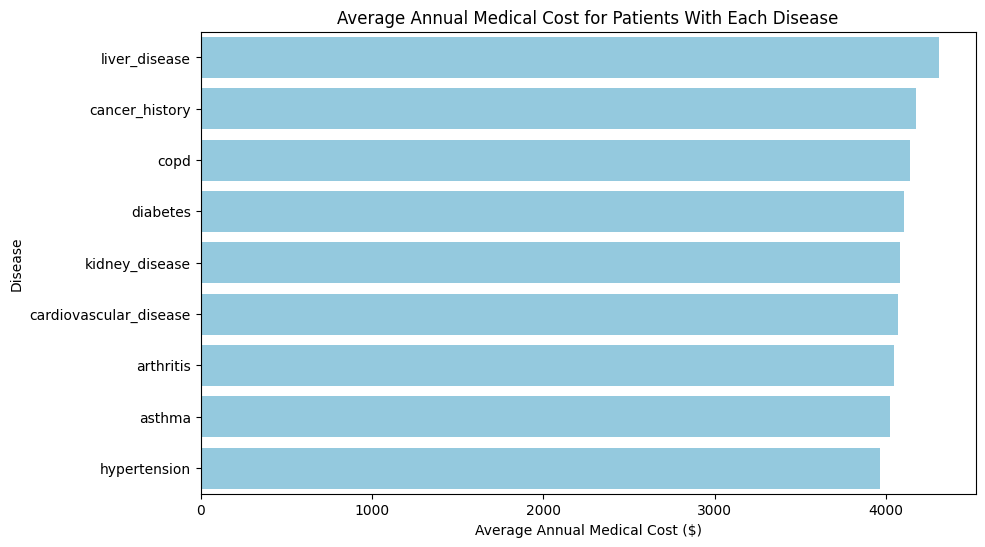

In [33]:
# Step 6: What is the Average Annual Medical Cost for each disease?

# I create a list of disease columns 
disease_cols = ['diabetes', 'hypertension', 'asthma', 'arthritis',
    'cancer_history', 'kidney_disease', 'liver_disease',
    'cardiovascular_disease', 'copd']

# I create a dictionary of avg costs for patients who have each disease
disease_avg_cost = {col: df[df[col] == 1]['annual_medical_cost'].mean()
    for col in disease_cols}

# Convert to DataFrame
disease_avg_cost = pd.DataFrame.from_dict(
    disease_avg_cost, orient='index', columns=['Avg Annual Cost']
).sort_values('Avg Annual Cost', ascending=False)

# I create the plot for visualization
plt.figure(figsize=(10,6))
sns.barplot(
    x=disease_avg_cost['Avg Annual Cost'],
    y=disease_avg_cost.index,
    color='skyblue')

plt.title("Average Annual Medical Cost for Patients With Each Disease")
plt.xlabel("Average Annual Medical Cost ($)")
plt.ylabel("Disease")
plt.show()

For chronic conditions, I calculated the average annual medical cost for patients who have each disease. This allowed me to clearly see which conditions are associated with the highest costs. Diseases like liver disease, cancer history, and copd showed the highest average costs, making them major cost drivers in this dataset. 

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset?  I noticed that some lifestyle factors (like smoking) had a stronger impact on medical cost than expected. I also learned that liver disease is the condition associated with the highest medical cost.
2. Do you have any concerns about your dataset?  The alcohol frequency column had about 30% missing values, while most other columns were complete. I replaced the missing values with a “No frequency” category since I needed to use that column for my visualization chart. Because this column had so many missing values, it may affect the accuracy of the results.
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data?  For the cleaning phase, I’ll need to check for outliers in BMI and medical charges, address skewed distributions. I will also check for missing or irregular values in key columns.